# Part 1: Persiapan Data dan Ekstraksi Atribut

In [ ]:
!pip install internetarchive
!ia list VogueRunway_dataset
!ia download VogueRunway_dataset --glob="*.parquet"

VogueRunway.parquet
VogueRunway_dataset.jpg
VogueRunway_dataset_archive.torrent
VogueRunway_dataset_files.xml
VogueRunway_dataset_meta.sqlite
VogueRunway_dataset_meta.xml
VogueRunway_dataset_thumb.jpg
__ia_thumb.jpg
img_emb/VogueRunway_image.npy
vogue_runway_000.tar
vogue_runway_001.tar
vogue_runway_002.tar
vogue_runway_003.tar
vogue_runway_004.tar
vogue_runway_005.tar
vogue_runway_006.tar
vogue_runway_007.tar
vogue_runway_008.tar
vogue_runway_009.tar
vogue_runway_010.tar
vogue_runway_011.tar
vogue_runway_012.tar
vogue_runway_013.tar
vogue_runway_014.tar
vogue_runway_015.tar
vogue_runway_016.tar
vogue_runway_017.tar
vogue_runway_018.tar
vogue_runway_019.tar
vogue_runway_020.tar
vogue_runway_021.tar
vogue_runway_022.tar
vogue_runway_023.tar
vogue_runway_024.tar
vogue_runway_025.tar
vogue_runway_026.tar
vogue_runway_027.tar
vogue_runway_028.tar
vogue_runway_029.tar
vogue_runway_030.tar
vogue_runway_031.tar
vogue_runway_032.tar
vogue_runway_033.tar
vogue_runway_034.tar
vogue_runway_035.ta

In [ ]:
import pandas as pd
df = pd.read_parquet("VogueRunway_dataset/VogueRunway.parquet")
print(df.shape)
print(df.columns.tolist())
df.head()

(1281633, 14)
['key', 'designer', 'season', 'year', 'category', 'city', 'section', 'width', 'height', 'size', 'aesthetic', 'tags', 'url', 'filename']


,key,designer,season,year,category,city,section,width,height,size,aesthetic,tags,url,filename
0,0000000,Louis Vuitton,Resort,2016,None,None,Collection,1366,2048,483749,6.51,"[Evening Dress, Clothing, Apparel, Fashion, Fe...",https://assets.vogue.com/photos/55c650b708298d...,0000000_Louis Vuitton - Resort 2016 [Collectio...
1,0000001,Preen by Thornton Bregazzi,Fall,2004,Ready-to-Wear,None,Collection,240,360,22795,3.46,"[Long Sleeve, Clothing, Apparel, Female, Perso...",https://assets.vogue.com/photos/55c6514b08298d...,0000001_Preen by Thornton Bregazzi - Fall 2004...
2,0000002,Zuhair Murad,Spring,2016,Ready-to-Wear,None,Collection,1333,2000,495006,5.91,"[Devon Windsor, Evening Dress, Clothing, Appar...",https://assets.vogue.com/photos/57eff9cc8cd3f4...,0000002_Zuhair Murad - Spring 2016 Ready-to-We...
3,0000003,Coach,Fall,2017,Ready-to-Wear,None,Details,2000,3000,969248,5.46,"[Clothing, Overcoat, Apparel, Jacket, Sleeve, ...",https://assets.vogue.com/photos/58a3a0075fc8e5...,0000003_Coach - Fall 2017 Ready-to-Wear [Detai...
4,0000004,Moschino,Resort,2016,None,None,Collection,1366,2048,523328,4.72,"[Stella Maxwell, Clothing, Footwear, Apparel, ...",https://assets.vogue.com/photos/55c650b908298d...,0000004_Moschino - Resort 2016 [Collection].jpg


In [ ]:
!ia download VogueRunway_dataset --glob="*VogueRunway_image.npy"

VogueRunway_dataset:
 skipping VogueRunway_dataset/img_emb/VogueRunway_image.npy, file already exists based on length and date.


In [ ]:
for c in ['section','category','season']:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False), "\n")

--- section ---
section
Collection    918509
Details       278380
Beauty         57933
Atmosphere     15117
Front Row      11694
Name: count, dtype: int64 

--- category ---
category
Ready-to-Wear    831562
Menswear         197254
None             187186
Couture           62437
Bridal             3194
Name: count, dtype: int64 

--- season ---
season
Spring      564990
Fall        558070
Resort       87196
Pre-Fall     71377
Name: count, dtype: int64 



In [ ]:
d = df.copy()
print("awal:", len(d))

d = d[d['section'] == 'Collection'];        print("setelah section:", len(d))
d = d[d['category'] == 'Ready-to-Wear'];    print("setelah category:", len(d))
d = d[d['season'].isin(['Spring','Fall'])]; print("setelah season:", len(d))
d = d[d['width'] >= 600];                   print("setelah width:", len(d))

d['season_std'] = d['season'].map({'Spring':'SS','Fall':'FW'})

awal: 1281633
setelah section: 918509
setelah category: 540900
setelah season: 540900
setelah width: 435438


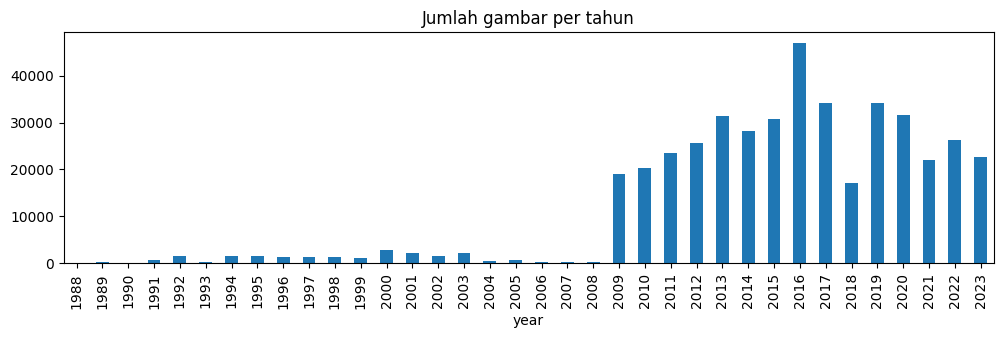

year
1988       78
1989      290
1990       85
1991      636
1992     1630
1993      198
1994     1480
1995     1643
1996     1339
1997     1318
1998     1406
1999     1125
2000     2775
2001     2271
2002     1438
2003     2233
2004      385
2005      712
2006      204
2007      267
2008      223
2009    19083
2010    20258
2011    23541
2012    25550
2013    31395
2014    28218
2015    30665
2016    46927
2017    34125
2018    17197
2019    34144
2020    31539
2021    22052
2022    26260
2023    22748
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
d.groupby('year').size().plot(kind='bar', figsize=(12,3), title='Jumlah gambar per tahun')
plt.show()
print(d.groupby('year').size())

In [ ]:
d = d[d['year'] >= 2009]
print(len(d))

413702


In [ ]:
top = d['designer'].value_counts().head(25)
print(top)

cov = (d[d['designer'].isin(top.index)]
       .groupby('designer')['year'].nunique()
       .sort_values(ascending=False))
print(cov)

designer
Dolce & Gabbana                             2817
Emporio Armani                              2418
Chanel                                      2338
Central Saint Martins                       2201
Giorgio Armani                              2188
Christian Dior                              1986
Burberry                                    1964
Valentino                                   1953
Gucci                                       1951
Michael Kors Collection                     1946
Balmain                                     1929
Dries Van Noten                             1815
Saint Laurent                               1785
Antonio Marras                              1693
Elie Saab                                   1665
Versace                                     1656
Andreas Kronthaler for Vivienne Westwood    1615
Moschino                                    1587
Givenchy                                    1576
Etro                                        1549
Balenciaga 

In [ ]:
DESIGNERS = ['Gucci', 'Balenciaga', 'Dries Van Noten']
sub = d[d['designer'].isin(DESIGNERS)]

print(len(sub))
print(sub.groupby(['year','season_std']).size().unstack(fill_value=0))
print()
print(sub.groupby(['designer','year']).size().unstack(fill_value=0))

5295
season_std   FW   SS
year                
2009        147  148
2010        140  136
2011        142  142
2012        147  137
2013        141  141
2014        127  136
2015        152  138
2016        181  355
2017        232  241
2018        238    0
2019        262  223
2020        232  270
2021        126  204
2022        204  233
2023        113  207

year             2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  \
designer                                                                      
Balenciaga         77    71    74    81    75    73    71   126   110    74   
Dries Van Noten   118   109   114   111   111   106   128   196   135    74   
Gucci             100    96    96    92    96    84    91   214   228    90   

year             2019  2020  2021  2022  2023  
designer                                       
Balenciaga        185   196   109   133    74  
Dries Van Noten   128   135   122   105   123  
Gucci             172   171    99   199   123  


In [ ]:
print(d[d['year']==2018]['season_std'].value_counts())

season_std
FW    17197
Name: count, dtype: int64


In [ ]:
pilot = (sub.groupby(['year','season_std'], group_keys=False)
            .apply(lambda g: g.sample(min(len(g), 8), random_state=42)))

if len(pilot) > 200:
    pilot = pilot.sample(n=200, random_state=42)

pilot = pilot.reset_index(drop=True)
pilot.to_csv('pilot_manifest.csv', index=False)

print(len(pilot))
print(pilot.groupby(['year','season_std']).size().unstack(fill_value=0))

200
season_std  FW  SS
year              
2009         7   7
2010         7   8
2011         7   8
2012         7   7
2013         7   7
2014         7   7
2015         5   7
2016         7   7
2017         6   8
2018         6   0
2019         7   7
2020         8   7
2021         5   8
2022         7   6
2023         7   6


/tmp/ipykernel_1143/857325671.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 8), random_state=42)))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/VogueRunway
!cp pilot_manifest.csv /content/drive/MyDrive/VogueRunway/
!cp VogueRunway_dataset/VogueRunway.parquet /content/drive/MyDrive/VogueRunway/
!ls -la /content/drive/MyDrive/VogueRunway/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total 97190
-rw------- 1 root root       90 Sep  8 07:43 eksperimen_ensemble.csv
-rw------- 1 root root     9275 Sep  8 07:33 ground_truth.csv
-rw------- 1 root root    69469 Sep  8 06:27 labels_pilot.csv
-rw------- 1 root root      191 Sep  8 06:30 margin_silhouette.csv
-rw------- 1 root root       22 Sep  8 07:08 noise_keys.json
-rw------- 1 root root    62041 Sep  8 09:03 pilot_manifest.csv
-rw------- 1 root root     1227 Sep  8 06:22 taxonomy.yaml
-rw------- 1 root root   133468 Sep  8 07:50 tren_panjang.png
-rw------- 1 root root   118685 Sep  8 07:50 tren_siluet.png
-rw------- 1 root root 99124491 Sep  8 09:03 VogueRunway.parquet


In [ ]:
import glob
paths = glob.glob('**/*VogueRunway_image.npy', recursive=True)
print(paths)

['VogueRunway_dataset/img_emb/VogueRunway_image.npy']


In [ ]:
import numpy as np

emb = np.load('VogueRunway_dataset/img_emb/VogueRunway_image.npy', mmap_mode='r')

print("emb    :", emb.shape)
print("parquet:", df.shape)

df['key_int'] = df['key'].astype(int)
print("key berurutan:", (df['key_int'].values == np.arange(len(df))).all())
print("key min/max  :", df['key_int'].min(), df['key_int'].max())

emb    : (1281633, 512)
parquet: (1281633, 15)
key berurutan: True
key min/max  : 0 1281632


In [ ]:
taxonomy_yaml = """
silhouette:
  oversized: ["a runway look with an oversized silhouette",
              "a model wearing loose, oversized clothing",
              "an outfit with a baggy, voluminous fit"]
  fitted:    ["a runway look with a fitted silhouette",
              "a model wearing tight, body-hugging clothing",
              "a close-fitting tailored outfit"]
  a_line:    ["an A-line silhouette that flares toward the hem",
              "a garment narrow at the top and wide at the bottom",
              "an A-line dress or skirt"]
  straight:  ["a straight, column-shaped silhouette",
              "an outfit with a straight vertical cut",
              "a simple straight-cut garment"]

length:
  mini:     ["a mini-length garment above the knee",
             "a very short hemline",
             "a short mini dress or skirt"]
  midi:     ["a midi-length garment between knee and ankle",
             "a mid-calf hemline",
             "a midi dress or skirt"]
  maxi:     ["a maxi-length garment reaching the floor",
             "a floor-length hemline",
             "a long maxi dress or skirt"]
  trousers: ["an outfit with trousers or pants",
             "a model wearing pants",
             "a trouser-based look"]
"""

with open('taxonomy.yaml', 'w') as f:
    f.write(taxonomy_yaml)

!cp taxonomy.yaml /content/drive/MyDrive/VogueRunway/
print(taxonomy_yaml)


silhouette:
  oversized: ["a runway look with an oversized silhouette",
              "a model wearing loose, oversized clothing",
              "an outfit with a baggy, voluminous fit"]
  fitted:    ["a runway look with a fitted silhouette",
              "a model wearing tight, body-hugging clothing",
              "a close-fitting tailored outfit"]
  a_line:    ["an A-line silhouette that flares toward the hem",
              "a garment narrow at the top and wide at the bottom",
              "an A-line dress or skirt"]
  straight:  ["a straight, column-shaped silhouette",
              "an outfit with a straight vertical cut",
              "a simple straight-cut garment"]

length:
  mini:     ["a mini-length garment above the knee",
             "a very short hemline",
             "a short mini dress or skirt"]
  midi:     ["a midi-length garment between knee and ankle",
             "a mid-calf hemline",
             "a midi dress or skirt"]
  maxi:     ["a maxi-length garment 

In [ ]:
!pip install -q open_clip_torch

In [ ]:
import yaml, torch, open_clip, numpy as np, pandas as pd

idx = pilot['key'].astype(int).values
img = np.array(emb[idx], dtype=np.float32)
img /= np.linalg.norm(img, axis=1, keepdims=True)
print("img embedding:", img.shape)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model = model.to(device).eval()
tok = open_clip.get_tokenizer('ViT-B-32')

tax = yaml.safe_load(open('taxonomy.yaml'))

for group, values in tax.items():
    names, vecs = [], []
    for val, prompts in values.items():
        with torch.no_grad():
            t = model.encode_text(tok(prompts).to(device)).float()
        t = t / t.norm(dim=-1, keepdim=True)
        v = t.mean(0); v = v / v.norm()
        names.append(val); vecs.append(v.cpu().numpy())

    sim = img @ np.stack(vecs).T
    pilot[group] = [names[i] for i in sim.argmax(1)]
    pilot[group + '_conf'] = sim.max(1)
    print(f"{group}: {names}")

pilot.to_csv('labels_pilot.csv', index=False)
!cp labels_pilot.csv /content/drive/MyDrive/VogueRunway/

pilot[['key','designer','year','season_std','silhouette','silhouette_conf','length','length_conf']].head(15)

img embedding: (200, 512)


/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


silhouette: ['oversized', 'fitted', 'a_line', 'straight']
length: ['mini', 'midi', 'maxi', 'trousers']


,key,designer,year,season_std,silhouette,silhouette_conf,length,length_conf
0,0790391,Dries Van Noten,2023,FW,a_line,0.264974,maxi,0.273520
1,0366794,Dries Van Noten,2013,FW,oversized,0.274074,trousers,0.280960
2,0443521,Dries Van Noten,2009,SS,fitted,0.274028,trousers,0.275152
3,0047004,Balenciaga,2020,FW,oversized,0.298421,trousers,0.300072
4,0301642,Gucci,2009,SS,oversized,0.273501,trousers,0.271528
5,0044618,Balenciaga,2022,FW,oversized,0.265043,midi,0.265044
6,0338965,Balenciaga,2010,SS,fitted,0.270257,mini,0.272437
7,0213478,Gucci,2021,SS,oversized,0.261687,midi,0.263249
8,1001894,Gucci,2019,FW,oversized,0.262433,maxi,0.262863
9,0075326,Gucci,2016,SS,fitted,0.266195,mini,0.252985


In [ ]:
print("=== silhouette ===")
print(pilot['silhouette'].value_counts(), "\n")
print("=== length ===")
print(pilot['length'].value_counts(), "\n")
print(pilot[['silhouette_conf','length_conf']].describe())

=== silhouette ===
silhouette
oversized    107
fitted        72
a_line        21
Name: count, dtype: int64 

=== length ===
length
trousers    99
maxi        75
mini        21
midi         5
Name: count, dtype: int64 

       silhouette_conf  length_conf
count       200.000000   200.000000
mean          0.275919     0.270226
std           0.012020     0.012922
min           0.217960     0.217388
25%           0.270599     0.263410
50%           0.276088     0.271083
75%           0.282106     0.278223
max           0.309942     0.314368


In [ ]:
srt = np.sort(sim, axis=1)
margin = srt[:,-1] - srt[:,-2]
print(pd.Series(margin).describe())

count    200.000000
mean       0.011947
std        0.009634
min        0.000058
25%        0.004750
50%        0.009379
75%        0.017350
max        0.047092
dtype: float64


In [ ]:
!cp labels_pilot.csv /content/drive/MyDrive/VogueRunway/
!ls -la /content/drive/MyDrive/VogueRunway/

total 97190
-rw------- 1 root root       90 Sep  8 07:43 eksperimen_ensemble.csv
-rw------- 1 root root     9275 Sep  8 07:33 ground_truth.csv
-rw------- 1 root root    69469 Sep  8 09:04 labels_pilot.csv
-rw------- 1 root root      191 Sep  8 06:30 margin_silhouette.csv
-rw------- 1 root root       22 Sep  8 07:08 noise_keys.json
-rw------- 1 root root    62041 Sep  8 09:03 pilot_manifest.csv
-rw------- 1 root root     1227 Sep  8 09:04 taxonomy.yaml
-rw------- 1 root root   133468 Sep  8 07:50 tren_panjang.png
-rw------- 1 root root   118685 Sep  8 07:50 tren_siluet.png
-rw------- 1 root root 99124491 Sep  8 09:03 VogueRunway.parquet


In [ ]:
margin_stats = pd.Series(margin).describe()
margin_stats.to_csv('margin_silhouette.csv')
!cp margin_silhouette.csv /content/drive/MyDrive/VogueRunway/

# Part 2: Anotasi Manual dan Evaluasi Kuantitatif

In [ ]:
import requests
r = requests.get(df.iloc[0]['url'], timeout=15)
print(r.status_code, len(r.content))

200 532406


In [ ]:
to_label = pilot.sample(50, random_state=7).reset_index(drop=True)

to_label = to_label[['key','designer','year','season_std','url','filename']]
to_label['gt_silhouette'] = ''
to_label['gt_length'] = ''

to_label.to_csv('to_label.csv', index=False)
print(len(to_label))
to_label.head()

50


,key,designer,year,season_std,url,filename,gt_silhouette,gt_length
0,0136361,Dries Van Noten,2012,FW,https://assets.vogue.com/photos/55c650e708298d...,0136361_Dries Van Noten - Fall 2012 Ready-to-W...,,
1,0378504,Balenciaga,2023,SS,https://assets.vogue.com/photos/6339b7e49a7db4...,0378504_Balenciaga - Spring 2023 Ready-to-Wear...,,
2,0845247,Gucci,2022,FW,https://assets.vogue.com/photos/621925f9583e40...,0845247_Gucci - Fall 2022 Ready-to-Wear [Colle...,,
3,1103301,Dries Van Noten,2010,FW,https://assets.vogue.com/photos/55c651bd08298d...,1103301_Dries Van Noten - Fall 2010 Ready-to-W...,,
4,0372273,Balenciaga,2020,FW,https://assets.vogue.com/photos/5e5ba0dfb6a434...,0372273_Balenciaga - Fall 2020 Ready-to-Wear [...,,


In [ ]:
import os, time

os.makedirs('imgs', exist_ok=True)
gagal = []

for _, row in to_label.iterrows():
    p = f"imgs/{row['key']}.jpg"
    if os.path.exists(p): continue
    try:
        r = requests.get(row['url'], timeout=20)
        if r.status_code == 200:
            open(p, 'wb').write(r.content)
        else:
            gagal.append((row['key'], r.status_code))
    except Exception as e:
        gagal.append((row['key'], str(e)))
    time.sleep(0.4)

print("berhasil:", len(os.listdir('imgs')), "| gagal:", len(gagal))
print(gagal[:10])

berhasil: 50 | gagal: 0
[]


In [ ]:
from IPython.display import Image, display

for k in to_label['key'].head(3):
    info = to_label[to_label['key']==k][['designer','year','season_std']].values[0]
    print(info)
    display(Image(f'imgs/{k}.jpg', width=300))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print(gt['key'].head())
print(os.listdir('imgs')[:3])

In [ ]:
import os
import pandas as pd

src = 'ground_truth.csv' if os.path.exists('ground_truth.csv') else 'to_label.csv'
gt = pd.read_csv(src, dtype={'key': str})

print(gt['key'].head())
print(gt['key'].dtype)

0    0136361
1    0378504
2    0845247
3    1103301
4    0372273
Name: key, dtype: object
object


# Manual Labeling

In [ ]:
import os
import pandas as pd
import ipywidgets as widgets
from IPython.display import Image, display, clear_output

gt = pd.read_csv('to_label.csv', dtype={'key': str})
gt['key'] = gt['key'].astype(str).str.zfill(7)
gt['gt_silhouette'] = ''
gt['gt_length'] = ''
gt.to_csv('ground_truth.csv', index=False)

ada = sum(os.path.exists(f"imgs/{k}.jpg") for k in gt['key'])
print(f"{ada}/{len(gt)} foto ditemukan")

SIL = ['oversized','fitted','a_line','straight','other']
LEN = ['mini','midi','maxi','trousers','other']

state = {'i': 0}

out      = widgets.Output()
sil_btns = widgets.ToggleButtons(options=SIL, description='Siluet:')
len_btns = widgets.ToggleButtons(options=LEN, description='Panjang:')
save_btn = widgets.Button(description='Simpan & lanjut', button_style='success')
back_btn = widgets.Button(description='← Mundur')
status   = widgets.Label()

def terisi(i):
    v = gt.loc[i, 'gt_silhouette']
    return pd.notna(v) and str(v).strip() != ''

def tampilkan():
    while state['i'] < len(gt) and terisi(state['i']):
        state['i'] += 1
    with out:
        clear_output(wait=True)
        if state['i'] >= len(gt):
            print("SELESAI — semua foto terlabeli")
            return
        r = gt.loc[state['i']]
        print(f"=== {state['i']+1}/{len(gt)} | {r['designer']} {r['season_std']}{r['year']} ===")
        display(Image(f"imgs/{r['key']}.jpg", width=340))

def simpan(_):
    if state['i'] >= len(gt):
        return
    gt.loc[state['i'], 'gt_silhouette'] = sil_btns.value
    gt.loc[state['i'], 'gt_length']     = len_btns.value
    gt.to_csv('ground_truth.csv', index=False)
    n = sum(terisi(j) for j in range(len(gt)))
    status.value = f"tersimpan ({n}/{len(gt)})"
    state['i'] += 1
    tampilkan()

def mundur(_):
    if state['i'] > 0:
        state['i'] -= 1
        gt.loc[state['i'], 'gt_silhouette'] = ''
        gt.loc[state['i'], 'gt_length'] = ''
        gt.to_csv('ground_truth.csv', index=False)
        status.value = f"kembali ke foto {state['i']+1}"
        with out:
            clear_output(wait=True)
            r = gt.loc[state['i']]
            print(f"=== {state['i']+1}/{len(gt)} | {r['designer']} {r['season_std']}{r['year']} ===")
            display(Image(f"imgs/{r['key']}.jpg", width=340))

save_btn.on_click(simpan)
back_btn.on_click(mundur)

display(out, sil_btns, len_btns,
        widgets.HBox([save_btn, back_btn]), status)
tampilkan()

In [ ]:
noise_keys = ['0093185','1009504']

import json
json.dump(noise_keys, open('noise_keys.json','w'))
!cp noise_keys.json /content/drive/MyDrive/VogueRunway/
print(len(noise_keys), "foto bermasalah tercatat")

2 foto bermasalah tercatat


In [ ]:
import pandas as pd
gt = pd.read_csv('ground_truth.csv', dtype={'key': str})

print("=== siluet (manual) ===")
print(gt['gt_silhouette'].value_counts(), "\n")
print("=== panjang (manual) ===")
print(gt['gt_length'].value_counts())

=== siluet (manual) ===
gt_silhouette
a_line       21
straight     11
fitted        8
oversized     8
other         2
Name: count, dtype: int64 

=== panjang (manual) ===
gt_length
trousers    22
midi        14
maxi         6
mini         6
other        2
Name: count, dtype: int64


In [ ]:
lab = pd.read_csv('labels_pilot.csv', dtype={'key': str})
lab['key'] = lab['key'].str.zfill(7)
gt['key']  = gt['key'].str.zfill(7)

m = gt.merge(lab[['key','silhouette','length']], on='key')
print("baris tergabung:", len(m))

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for a in ['silhouette','length']:
    print(f"\n{'='*40}\n{a.upper()}")
    print("Akurasi:", round(accuracy_score(m[f'gt_{a}'], m[a]), 3))
    print("\nConfusion matrix:")
    print(pd.crosstab(m[f'gt_{a}'], m[a], rownames=['manual'], colnames=['CLIP']))

baris tergabung: 50

SILHOUETTE
Akurasi: 0.3

Confusion matrix:
CLIP       a_line  fitted  oversized
manual                              
a_line          2       8         11
fitted          0       7          1
other           1       1          0
oversized       0       2          6
straight        0       5          6

LENGTH
Akurasi: 0.5

Confusion matrix:
CLIP      maxi  midi  mini  trousers
manual                              
maxi         5     1     0         0
midi         8     0     1         5
mini         1     0     4         1
other        0     1     0         1
trousers     6     0     0        16


In [ ]:
print(pd.crosstab(gt['gt_silhouette'], gt['gt_length']))

gt_length      maxi  midi  mini  other  trousers
gt_silhouette                                   
a_line            5     7     3      0         6
fitted            1     3     2      0         2
other             0     0     0      2         0
oversized         0     3     0      0         5
straight          0     1     1      0         9


In [ ]:
from sklearn.metrics import accuracy_score

mm = m[~m['gt_silhouette'].isin(['other','straight'])]
print("siluet tanpa other+straight:", round(accuracy_score(mm['gt_silhouette'], mm['silhouette']),3), f"(n={len(mm)})")

mn = m[m['gt_length'] != 'other']
print("panjang tanpa other:", round(accuracy_score(mn['gt_length'], mn['length']),3), f"(n={len(mn)})")

print()
for a in ['silhouette','length']:
    base = m[f'gt_{a}'].value_counts(normalize=True).max()
    acc  = accuracy_score(m[f'gt_{a}'], m[a])
    print(f"{a}: CLIP {acc:.3f} vs baseline {base:.3f}")

siluet tanpa other+straight: 0.405 (n=37)
panjang tanpa other: 0.521 (n=48)

silhouette: CLIP 0.300 vs baseline 0.420
length: CLIP 0.500 vs baseline 0.440


In [ ]:
import yaml, torch, open_clip, numpy as np

tax = yaml.safe_load(open('taxonomy.yaml'))
idx = pilot['key'].astype(int).values
img = np.array(emb[idx], dtype=np.float32)
img /= np.linalg.norm(img, axis=1, keepdims=True)

hasil = {}
for mode in ['ensemble','single']:
    tmp = pilot[['key']].copy()
    for group, values in tax.items():
        names, vecs = [], []
        for val, prompts in values.items():
            p = prompts if mode=='ensemble' else prompts[:1]
            with torch.no_grad():
                t = model.encode_text(tok(p).to(device)).float()
            t = t / t.norm(dim=-1, keepdim=True)
            v = t.mean(0); v = v / v.norm()
            names.append(val); vecs.append(v.cpu().numpy())
        sim = img @ np.stack(vecs).T
        tmp[group] = [names[i] for i in sim.argmax(1)]
    hasil[mode] = tmp

for mode, tmp in hasil.items():
    tmp['key'] = tmp['key'].astype(str).str.zfill(7)
    mrg = gt.merge(tmp, on='key')
    s = accuracy_score(mrg['gt_silhouette'], mrg['silhouette'])
    l = accuracy_score(mrg['gt_length'], mrg['length'])
    print(f"{mode:9s} → siluet {s:.3f} | panjang {l:.3f}")

ensemble  → siluet 0.300 | panjang 0.500
single    → siluet 0.260 | panjang 0.380


In [ ]:
import pandas as pd
tabel = pd.DataFrame({
    'metode': ['prompt tunggal','prompt ensemble','baseline'],
    'siluet': [0.260, 0.300, 0.420],
    'panjang': [0.380, 0.500, 0.440]
})
tabel.to_csv('eksperimen_ensemble.csv', index=False)
!cp eksperimen_ensemble.csv /content/drive/MyDrive/VogueRunway/
tabel

,metode,siluet,panjang
0,prompt tunggal,0.26,0.38
1,prompt ensemble,0.30,0.50
2,baseline,0.42,0.44


# Part 3: Visualisasi


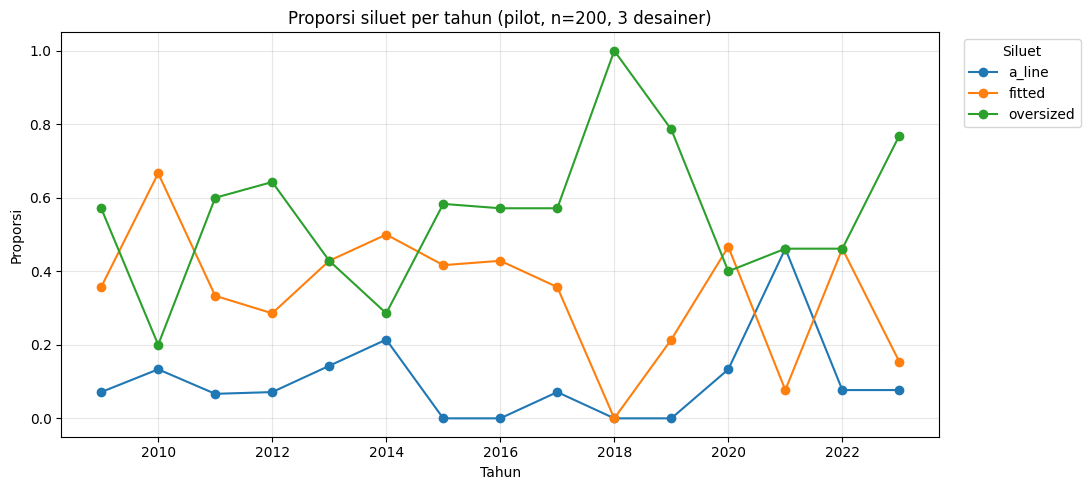

In [ ]:
import matplotlib.pyplot as plt

prop = (pilot.groupby('year')['silhouette']
             .value_counts(normalize=True).unstack().fillna(0))

ax = prop.plot(marker='o', figsize=(11,5))
ax.set_title('Proporsi siluet per tahun (pilot, n=200, 3 desainer)')
ax.set_xlabel('Tahun'); ax.set_ylabel('Proporsi')
ax.legend(title='Siluet', bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tren_siluet.png', dpi=150, bbox_inches='tight')
plt.show()

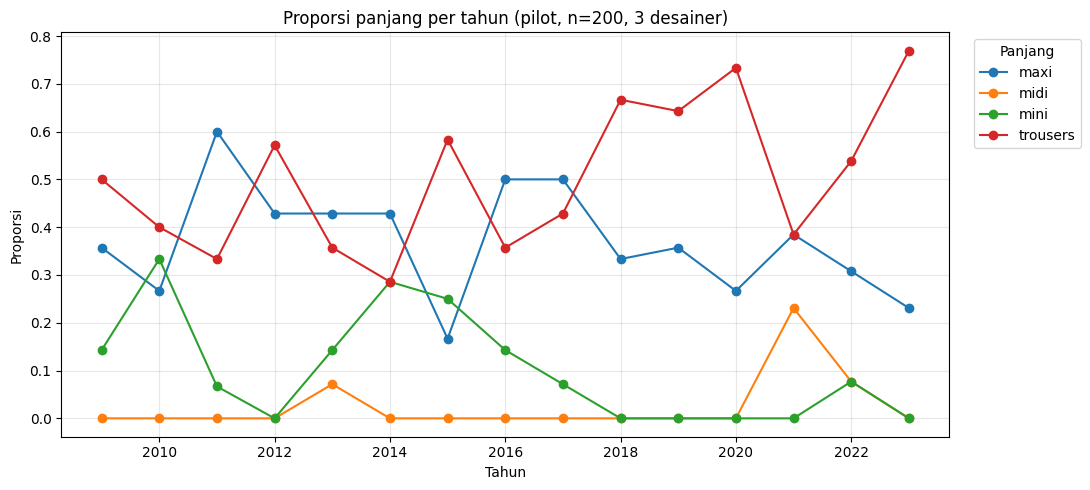

In [ ]:
prop2 = (pilot.groupby('year')['length']
              .value_counts(normalize=True).unstack().fillna(0))

ax = prop2.plot(marker='o', figsize=(11,5))
ax.set_title('Proporsi panjang per tahun (pilot, n=200, 3 desainer)')
ax.set_xlabel('Tahun'); ax.set_ylabel('Proporsi')
ax.legend(title='Panjang', bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tren_panjang.png', dpi=150, bbox_inches='tight')
plt.show()